# Version with water under the prism

# Interferometric Reflectivity Dip : beam narrowing observable determination

The objective of this notebook is to evaluate the impact of the beam narrowing effect on the resolution of SPR-based sensors and to provide insights into its potential applications.

### Importation of the needed libraries

PyMoosh is a open source, user-friendly library for the optical study of multilayered structures, written in Python. The "my_module" library corresponds to a module which contains home made functions needed for this work.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.fft import fft2, fftshift, ifft2
from scipy.integrate import trapezoid
import PyMoosh as PM
import my_module as my_mod
from joblib import Parallel, delayed
from tqdm import tqdm
import multiprocessing

font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 18}

plt.rc('font', **font)

SAVE_MODE = True # state variable to set if the plots are saved in separated files
save_formats = ["pdf", "svg"] # list with the formats to use to save plots

# define the number of CPU core to use for multiprocessing
total_cores = multiprocessing.cpu_count()
reserved_cores = 4  # number of CPU core reserved for the system
n_jobs = max(1, total_cores - reserved_cores)

### Observable determination

One easy envisageable experiment is to perform measurements by varying the incidence angle. The goal is to find an experimentally accessible observable which can unravel the beam narrowing.

The observable measurements will be realised after the second optical system in the real world, but as the effect of the second optical system can be reduced to an enlargement of the x and y scales, it is enough to perform our search just after the reflection (to be coherent on the effect visualisation each axis is inverted because the second optical system magnification is negative). In this notebook the first optical system is also not simulated completely, his magnification is directly considered on the waists before the reflection in order to have an observable search which corresponds to the system determined (it is also possible to consider the ideal theoretical waist in place depending on your goal).

In [2]:
# initialisation of the needed parameters, other than the incidence,
n1 = 1 # air refractive index
n2 = 1.515  # glass refractive index
wavelength = 632.8
k0 = 2 * np.pi / wavelength
N = 100
alpha0 = 0
beta0 = 0
x0 = 0
y0 = 0
w = 5690*8.118 # the waist before reflection corresponding to the experimental setup defined
# w = 46089 # the optimal waist before reflection
wx = w
wy = w
d = 400000

# the x and y-axes considered
x = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
y = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
# grids of the axes
X, Y = np.meshgrid(x, y)

# definition of the spectral grid
pask = 2 * np.pi / d  # definition of the spectral step
a = np.arange(-N, N + 1) * pask  # alpha (kx) range in nm-1
b = a  # beta (ky) range in nm-1
A, B = np.meshgrid(a, b)  # alpha and beta grid

# definition of the structure on which the reflection is done
# get the material from refractiveindex database (RII) when possible
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
h_Au = 47
mat = ["BK7",Cr,Au,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33**2 is for water
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000, 2, h_Au, 1000]  # thickness of each layer
structure = PM.Structure(mat, stack, thickness, verbose=False)

Determination of the local minimum intensity (and neighbors) indices at 44.1°. In order to know where to look for the observables.

In [3]:
kz = ((n2 * k0) ** 2 - A**2 - B**2) ** (1 / 2)
inc = 73.38
theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2)/ (n2 * k0))  # array with the incidence angle for all incident plane wave
cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
# determination of the reflection coefficients for each plane wave
for i in range(len(a)):
    for j in range(len(b)):
        r, t, R, T = PM.coefficient(structure, wavelength, theta[i,j], 1)
        cr[i, j] = r
U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0) # spatial beam before reflection
U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
U1ki=cr*U1k # spectral beam after reflection
U1i=ifft2(U1ki) # spatial beam after reflection
# determination of the light intensity (reverted to correspond ta take into account the sign of the second optical system magnification)
I = (np.abs(U1i)**2)[::-1, ::-1]
I_rel = I/np.max(I)
index_max_x, index_max_y = np.unravel_index(np.argmax(I), I_rel.shape) # line index (axis 0) and column index (axis 1) corresponding to the maximum intensity 
# search of the indices corresponding to the local minimum of intensities to build observables (the search is done from the max position towards the effect direction)
# first observables : light intensity around local minimum (on the xmax line)
# searching of the local minimum indices
index_loc_min_y=0
if(index_max_y<N):
    for i in range(index_max_y,2*N+1,1):
        if((I_rel[index_max_x,i-1]>I_rel[index_max_x,i])and(I_rel[index_max_x,i+1]>I_rel[index_max_x,i])):
            print(f"Local min of light intensity on the x axis with max found at ({index_max_x, i}) with a relative intensity of {I_rel[index_max_x,i]}")
            index_loc_min_y = i
            break
else:
    for i in range(index_max_y,0,-1):
        if((I_rel[index_max_x,i-1]>I_rel[index_max_x,i])and(I_rel[index_max_x,i+1]>I_rel[index_max_x,i])):
            print(f"Local min of light intensity on the x axis with max found at ({index_max_x, i}) with a relative intensity of {I_rel[index_max_x,i]}")
            index_loc_min_y = i
            break
# second observables : light intensity projected on x (sum on the y) around local minimum
I_proj_x = np.sum(I, axis=0)
I_proj_x_rel = I_proj_x / np.max(I_proj_x)
ind_proj_max = np.argmax(I_proj_x)
ind_proj_loc_min = 0
if(ind_proj_max<N):
    for i in range(ind_proj_max,2*N+1,1):
        if((I_proj_x_rel[i-1]>I_proj_x_rel[i])and(I_proj_x_rel[i+1]>I_proj_x_rel[i])):
            print(f"Local min of light intensity projected on x found at ({i}) with a relative intensity of {I_proj_x_rel[i]}")
            ind_proj_loc_min = i
            break
else:
    for i in range(ind_proj_max,0,-1):
        if((I_proj_x_rel[i-1]>I_proj_x_rel[i])and(I_proj_x_rel[i+1]>I_proj_x_rel[i])):
            print(f"Local min of light intensity projected on x found at ({i}) with a relative intensity of {I_proj_x_rel[i]}")
            ind_proj_loc_min = i
            break



Local min of light intensity on the x axis with max found at ((np.int64(100), 79)) with a relative intensity of 0.00011234967959487303
Local min of light intensity projected on x found at (79) with a relative intensity of 0.00011189468996970868


Determination of the enlargements and possible observables as function of the incidence angle.

In [4]:
# initialisation
inc_range = np.linspace(71, 75, int((75 - 71) / 0.01) + 1)  # range of incidence considered
ELx = []
num_neighbors = 20
I_REL_min = np.empty((0, num_neighbors + 1))
I_PROJ_REL_min = np.empty((0, num_neighbors + 1))

kz = ((n2 * k0) ** 2 - A**2 - B**2) ** (1 / 2)  # determination of the wave vector z component (kz or gamma) for all incident plane wave

def process_one_inc(inc):
    # reflection
    theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2) / (n2 * k0))  # array with the incidence angle for all incident plane wave
    cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
    # determination of the reflection coefficients for each plane wave
    for i in range(len(a)):
        for j in range(len(b)):
            r, t, R, T = PM.coefficient(structure, wavelength, theta[i, j], 1)
            cr[i, j] = r
    U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0)  # spatial beam before reflection
    U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1)  # spectral beam before reflection
    U1ki = cr * U1k  # spectral beam after reflection
    U1i = ifft2(U1ki)  # spatial beam after reflection

    # determination of the barycentre of the beam on x and y for the incoming and the reflected beam
    bxU1  = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    byU1  = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)

    # determination of the shift
    decx = bxU1i - bxU1
    decy = byU1i - byU1

    # determination of the enlargement (in absolute and relative form)
    elarrelatx = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
    elarrelaty = (trapezoid(trapezoid(((Y - decy)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((Y**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))

    # save of the x enlargement
    # determination of the light intensity (reverted to take into account the sign of the second optical system magnification)
    I = (np.abs(U1i)**2)[::-1, ::-1]
    I_rel = I / np.max(I)

    # observables = relative intensities at local minimum and neighbors towards the max
    # save of the first observables : light intensity around local minimum (on the xmax line at 44.1)
    if index_max_y < N:
        I_rel_min_line = I_rel[index_max_x, index_loc_min_y:index_loc_min_y - num_neighbors - 1:-1]
    else:
        I_rel_min_line = I_rel[index_max_x, index_loc_min_y:index_loc_min_y + num_neighbors + 1:1]

    # save of the second observables : light intensity projected on x (sum on the y) around local minimum
    I_proj_x = np.sum(I, axis=0)
    I_proj_x_rel = I_proj_x / np.max(I_proj_x)

    if ind_proj_max < N:
        I_proj_rel_min_line = I_proj_x_rel[ind_proj_loc_min:ind_proj_loc_min - num_neighbors - 1:-1]
    else:
        I_proj_rel_min_line = I_proj_x_rel[ind_proj_loc_min:ind_proj_loc_min + num_neighbors + 1:1]

    return elarrelatx, I_rel_min_line, I_proj_rel_min_line

results = Parallel(n_jobs=n_jobs)(delayed(process_one_inc)(inc) for inc in tqdm(inc_range, desc="Scan of all the incidences"))

for elx, Irel, Iproj in results:
    ELx.append(elx)
    I_REL_min = np.append(I_REL_min, [Irel], axis=0)
    I_PROJ_REL_min = np.append(I_PROJ_REL_min, [Iproj], axis=0)


Scan of all the incidences: 100%|██████████| 401/401 [05:18<00:00,  1.26it/s]


The best relative intensity observable is for Neighbor 14 with max - min = 0.5024550757486858.
The best ptojected relative intensity observable is for Neighbor 14 with max - min = 0.5024462324756299.


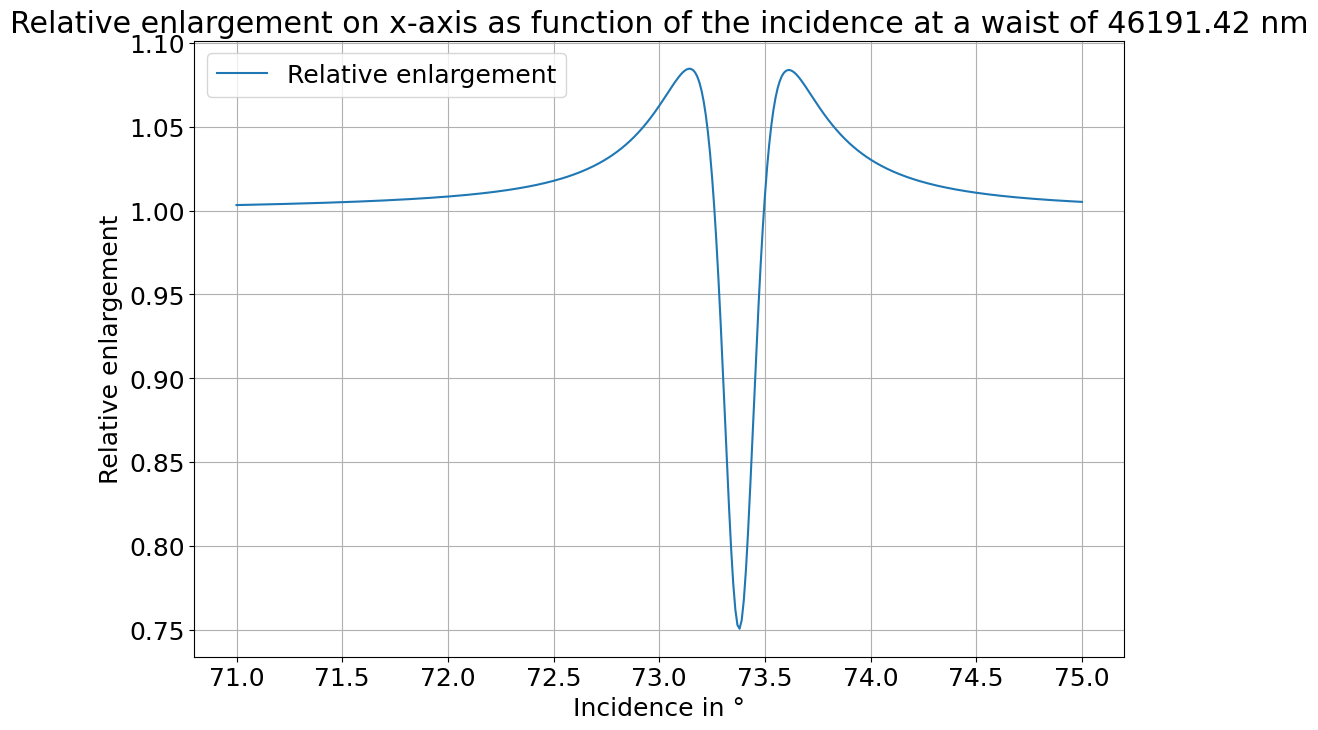

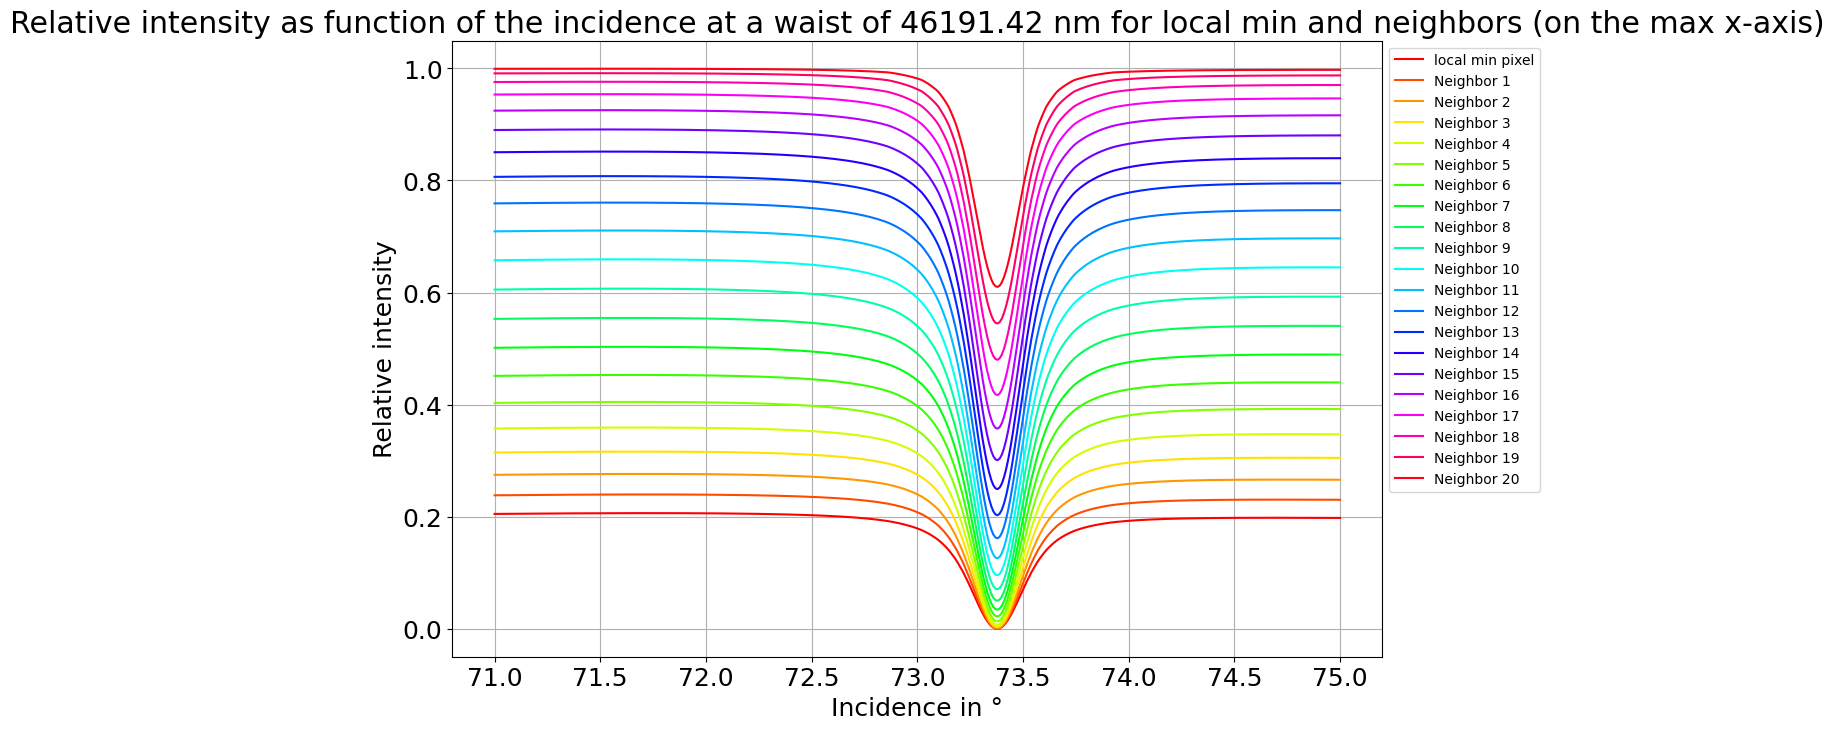

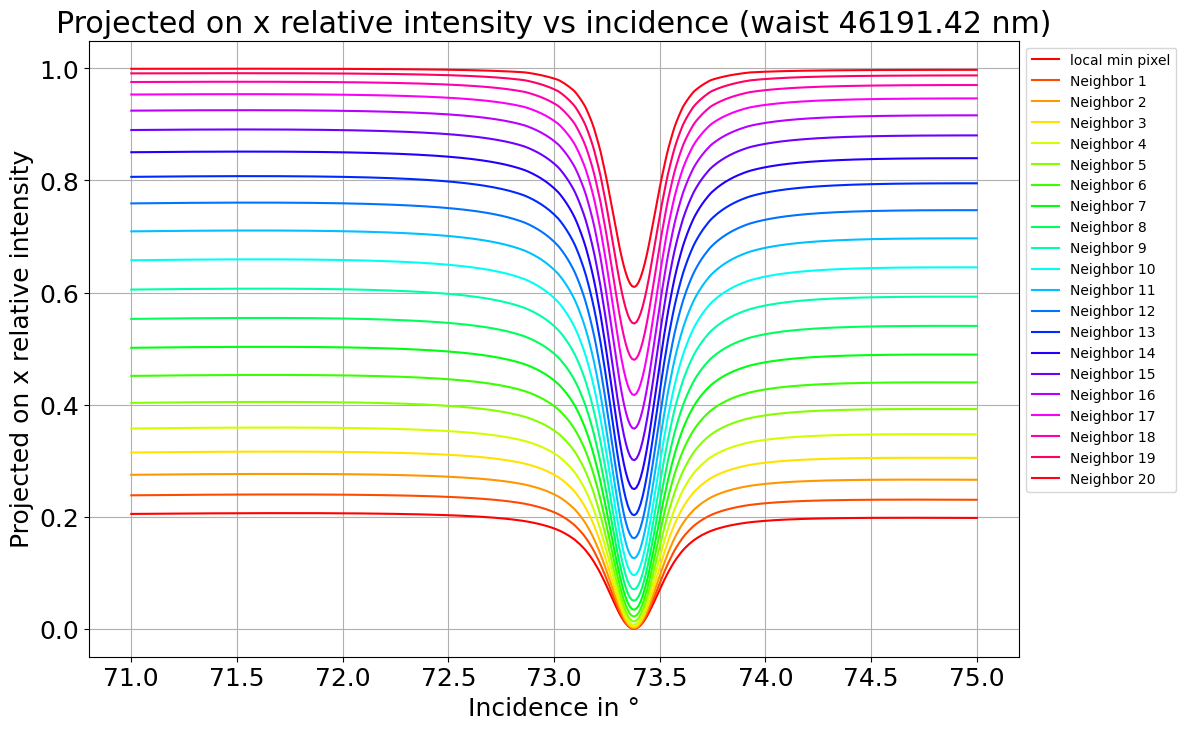

In [5]:
plt.figure(figsize=(12,8))
plt.plot(inc_range, np.array(ELx), label="Relative enlargement")
plt.title(f"Relative enlargement on x-axis as function of the incidence at a waist of {w} nm")
plt.xlabel("Incidence in °")
plt.ylabel("Relative enlargement")
plt.grid()
plt.legend();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_sensitivity/x_rel_enlargement.{file_ext}", bbox_inches="tight")

# where to look for the best neighbors (we are interested in  the dip area)
inc_dip_low_lim = 73.1
inc_dip_high_lim = 73.7

line_label=[f"Neighbor {i}" for i in range(0,num_neighbors+1)]
line_label[0]="local min pixel"
plt.figure(figsize=(12,8))
colors = plt.get_cmap("hsv", num_neighbors+1)
for i in range(0,num_neighbors+1):
    plt.plot(inc_range,I_REL_min[:,i], color=colors(i), label=line_label[i])
plt.title(f"Relative intensity as function of the incidence at a waist of {w} nm for local min and neighbors (on the max x-axis)")
plt.xlabel("Incidence in °")
plt.ylabel("Relative intensity")
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=10);
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_sensitivity/rel_intensity_around_local_min.{file_ext}", bbox_inches="tight")
max_min_dif=np.max(I_REL_min[(inc_range>inc_dip_low_lim)&(inc_range<inc_dip_high_lim)], axis=0)-np.min(I_REL_min[(inc_range>inc_dip_low_lim)&(inc_range<inc_dip_high_lim)], axis=0)
best_index=np.argmax(max_min_dif)
print(f"The best relative intensity observable is for {line_label[best_index]} with max - min = {max_min_dif[best_index]}.")

plt.figure(figsize=(12,8))
colors = plt.get_cmap("hsv", num_neighbors+1)
for i in range(0,num_neighbors+1):
    plt.plot(inc_range,I_PROJ_REL_min[:,i], color=colors(i), label=line_label[i])
plt.title(f"Projected on x relative intensity vs incidence (waist {w} nm)")
plt.xlabel("Incidence in °")
plt.ylabel("Projected on x relative intensity")
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=10);
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_sensitivity/projected_rel_intensity_around_local_min.{file_ext}", bbox_inches="tight")
max_min_dif=np.max(I_PROJ_REL_min[(inc_range>inc_dip_low_lim)&(inc_range<inc_dip_high_lim)], axis=0)-np.min(I_PROJ_REL_min[(inc_range>inc_dip_low_lim)&(inc_range<inc_dip_high_lim)], axis=0)
best_index=np.argmax(max_min_dif)
print(f"The best ptojected relative intensity observable is for {line_label[best_index]} with max - min = {max_min_dif[best_index]}.")


In [6]:
num_best_neighbor = best_index

## Sensitivity determination

The sensitivity of a SPR based sensor can be defined experimentally as:
\begin{equation*}
S=\frac{\delta Y}{\delta n},
\end{equation*}
where $\delta Y$ is the variation of a given experimental quantity when a refractive index variation $\delta n$ is applied.

The determinations of this work will be done at a given incidence angle, and there it is smart to choose an angle corresponding to a linear part of the observables around the minimum values. Here an angle lying on the left of the minimum will be considered (44°).

### The second structures needed for the determination

The sensitivity definition imply to determine the quantity $Y$ for two slightly different refractive indices $n$ of the external middle (air behind the prism-chromium-gold here). In order to do that a variation of the structure on which the reflection is done considering $n_{H_2O}=1.33+0.001$ instead of $1.33$.

In [7]:
n_variation = 0.001

mat2 = ["BK7",Cr,Au,(1.33+n_variation)**2]  # same list of material as before but with a slight modification of the water permittivity
structure2 = PM.Structure(mat2, stack, thickness, verbose=False)

### Base sensitivity

A basic experimental quantity used for the sensitivity determination is the reflectance. 

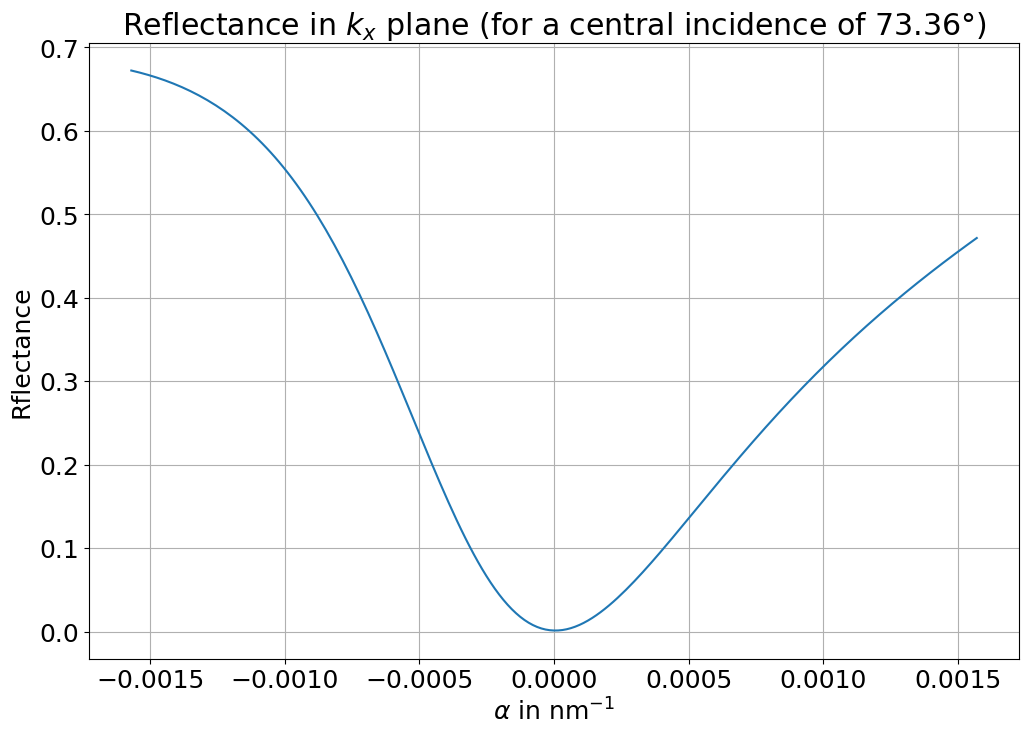

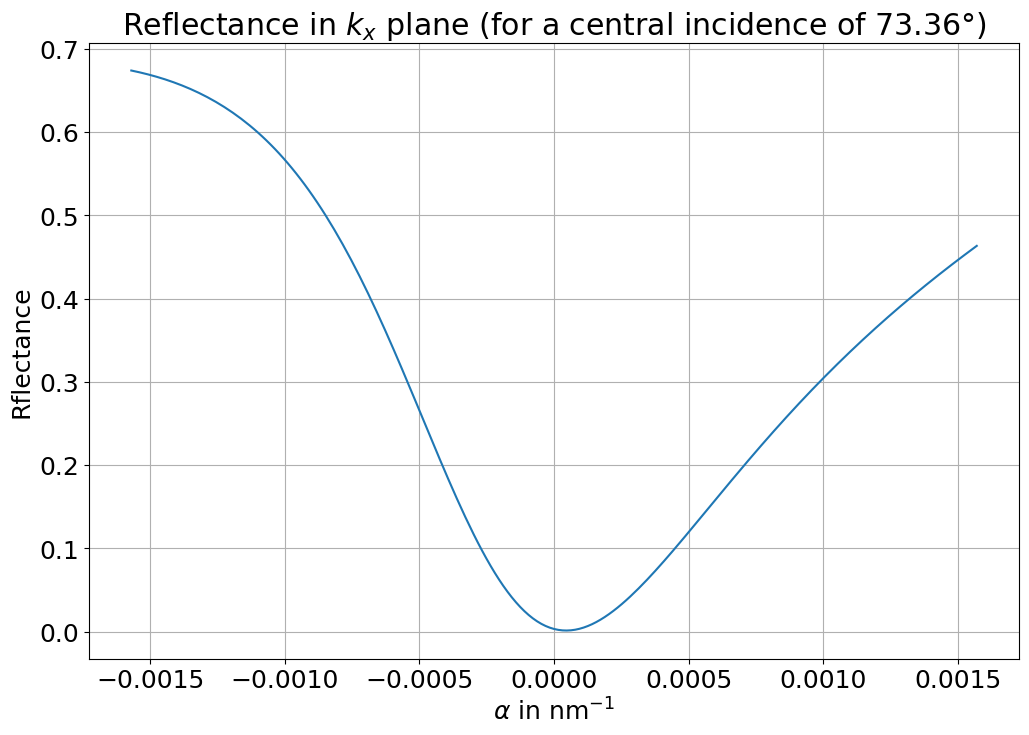

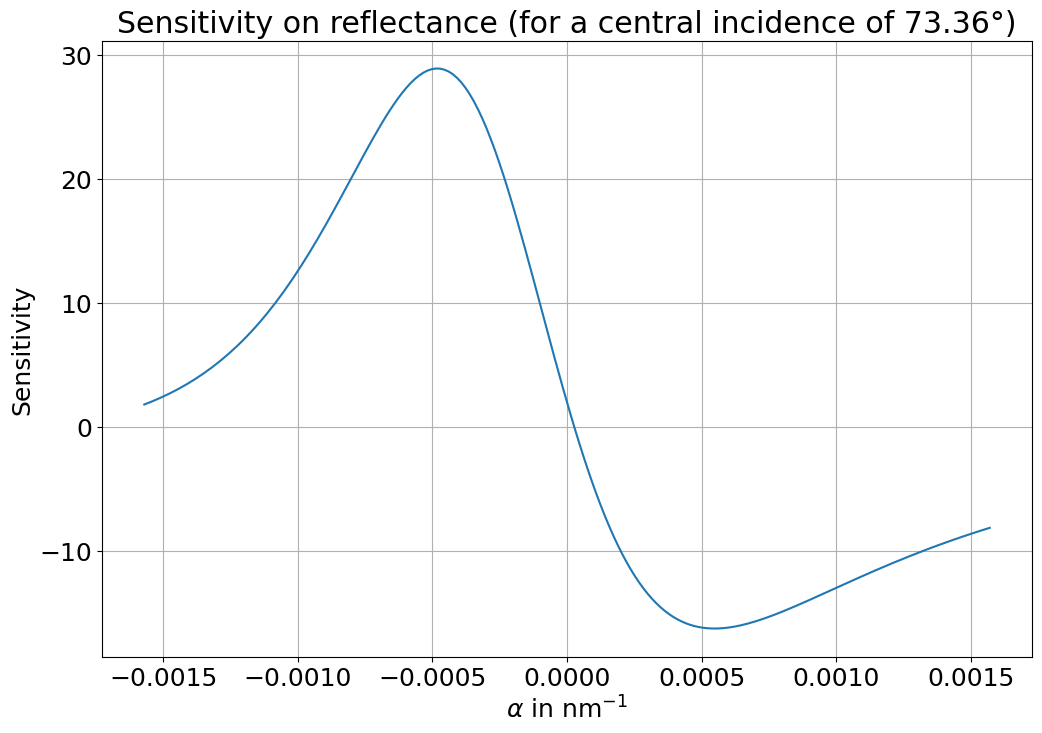

In [8]:
kz = ((n2 * k0) ** 2 - A**2 - B**2) ** (1 / 2)
inc = 73.36
theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2)/ (n2 * k0))  # array with the incidence angle for all incident plane wave
cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
cr2 = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
# determination of the reflection coefficients for each plane wave
for i in range(len(a)):
    for j in range(len(b)):
        r, t, R, T = PM.coefficient(structure, wavelength, theta[i,j], 1)
        r2, t2, R2, T2 = PM.coefficient(structure2, wavelength, theta[i,j], 1)
        cr[i, j] = r
        cr2[i, j] = r2

cr1D = np.abs(cr[N,:])**2
cr21D = np.abs(cr2[N,:])**2

plt.figure(figsize=(12,8))
plt.plot(a,cr1D)
plt.title(fr"Reflectance in $k_x$ plane (for a central incidence of {inc}°)")
plt.xlabel(r"$\alpha$ in $\mathrm{nm}^{-1}$")
plt.ylabel(fr"Rflectance")
plt.grid();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_sensitivity/R_base.{file_ext}", bbox_inches="tight")

plt.figure(figsize=(12,8))
plt.plot(a,cr21D)
plt.title(fr"Reflectance in $k_x$ plane (for a central incidence of {inc}°)")
plt.xlabel(r"$\alpha$ in $\mathrm{nm}^{-1}$")
plt.ylabel(fr"Rflectance")
plt.grid();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_sensitivity/R_variant.{file_ext}", bbox_inches="tight")

plt.figure(figsize=(12,8))
plt.plot(a,(cr21D-cr1D)/n_variation)
plt.title(fr"Sensitivity on reflectance (for a central incidence of {inc}°)")
plt.xlabel(r"$\alpha$ in $\mathrm{nm}^{-1}$")
plt.ylabel(fr"Sensitivity")
plt.grid();

In [9]:
S_base = (cr21D[N]-cr1D[N])/(n_variation)
print(f"The sensitivity determined on reflectance at an incidence of {inc}° for a refractive index variation of {n_variation} is {S_base}")

The sensitivity determined on reflectance at an incidence of 73.36° for a refractive index variation of 0.001 is 1.987258306548027


In [10]:
inc_best = 72.75
theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc_best)) + kz * np.sin(np.deg2rad(inc_best))) ** 2 + B**2)/ (n2 * k0))  # array with the incidence angle for all incident plane wave
cr_best = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
cr2_best = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
# determination of the reflection coefficients for each plane wave
for i in range(len(a)):
    for j in range(len(b)):
        r, t, R, T = PM.coefficient(structure, wavelength, theta[i,j], 1)
        r2, t2, R2, T2 = PM.coefficient(structure2, wavelength, theta[i,j], 1)
        cr_best[i, j] = r
        cr2_best[i, j] = r2

cr1D_best = np.abs(cr_best[N,:])**2
cr21D_best = np.abs(cr2_best[N,:])**2

In [11]:
S_base_best = (cr21D_best[N]-cr1D_best[N])/(n_variation)
print(f"The sensitivity determined on the reflectance at an incidence of {inc_best}° for a refractive index variation of {n_variation} is {S_base_best}")

The sensitivity determined on the reflectance at an incidence of 72.75° for a refractive index variation of 0.001 is 14.706993919284903


### Observables sensitivities

Determination of the observables for the first structure

In [12]:
U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0) # spatial beam before reflection
U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
U1ki=cr*U1k # spectral beam after reflection
U1i=ifft2(U1ki) # spatial beam after reflection
# determination of the barycentre of the beam on x and y for the incoming and the reflected beam
bxU1  = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
byU1  = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
# determination of the shift
decx=bxU1i-bxU1
decy=byU1i-byU1
# determination of the relative enlargement
elarrelatx_1 = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
# determination of the light intensity (reverted to take into account the sign of the second optical system magnification)
I = (np.abs(U1i)**2)[::-1, ::-1]
I_rel = I/np.max(I)
# observables = relative intensities at local minimum and neighbors towards the max
# save of the first observables : light intensity around local minimum (on the xmax line at 44.37)
if(index_max_y<N):
    I_rel_min_1=I_rel[index_max_x, index_loc_min_y - num_best_neighbor]
else:
    I_rel_min_1=I_rel[index_max_x, index_loc_min_y + num_best_neighbor]
# save of the second observables : light intensity projected on x (sum on the y) around local minimum
I_proj_x = np.sum(I, axis=0)
I_proj_x_rel = I_proj_x / np.max(I_proj_x)
if(ind_proj_max<N):
    I_proj_rel_min_1 = I_proj_x_rel[ind_proj_loc_min - num_best_neighbor]
else:
    I_proj_rel_min_1 = I_proj_x_rel[ind_proj_loc_min + num_best_neighbor]

Determination of the observables for the second structure.

In [13]:
U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0) # spatial beam before reflection
U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
U1ki=cr2*U1k # spectral beam after reflection
U1i=ifft2(U1ki) # spatial beam after reflection
# determination of the barycentre of the beam on x and y for the incoming and the reflected beam
bxU1  = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
byU1  = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
# determination of the shift
decx=bxU1i-bxU1
decy=byU1i-byU1
# determination of the relative enlargement
elarrelatx_2 = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
# determination of the light intensity (reverted to take into account the sign of the second optical system magnification)
I = (np.abs(U1i)**2)[::-1, ::-1]
I_rel = I/np.max(I)
# observables = relative intensities at local minimum and neighbors towards the max
# save of the first observables : light intensity around local minimum (on the xmax line at 44.37)
if(index_max_y<N):
    I_rel_min_2=I_rel[index_max_x, index_loc_min_y - num_best_neighbor]
else:
    I_rel_min_2=I_rel[index_max_x, index_loc_min_y + num_best_neighbor]
# save of the second observables : light intensity projected on x (sum on the y) around local minimum
I_proj_x = np.sum(I, axis=0)
I_proj_x_rel = I_proj_x / np.max(I_proj_x)
if(ind_proj_max<N):
    I_proj_rel_min_2 = I_proj_x_rel[ind_proj_loc_min - num_best_neighbor]
else:
    I_proj_rel_min_2 = I_proj_x_rel[ind_proj_loc_min + num_best_neighbor]

Results:

In [14]:
S_enlarg = (elarrelatx_2-elarrelatx_1)/(n_variation)
S_I_rel_min = (I_rel_min_2-I_rel_min_1)/(n_variation)
S_I_proj_rel_min = (I_proj_rel_min_2-I_proj_rel_min_1)/(n_variation)

In [15]:
print(f"Summary of the sensitivities determined at an incidence of {inc}° for a refractive index variation of {n_variation}:")
print(f"- reflectance: {S_base:.2f}")
print(f"- relative enlargement on x-axis: {S_enlarg:.2f}")
print(f"- relative light intensity at {best_index} pixels from the local minimum at 73.38°: {S_I_rel_min:.2f}")
print(f"- relative light intensity projected on x-axis at {best_index} pixels from the local minimum at 73.38°: {S_I_proj_rel_min:.2f}")
print(f"- reflectance at the best incidence for it {inc_best}°: {S_base_best:.2f}")
print("")
print("Sensitivity improvement in % vs reflectance at best incidence:")
print(f"- relative enlargement on x-axis: {abs(S_enlarg/S_base_best)*100-100:.2f} %")
print(f"- relative light intensity at {best_index} pixels from the local minimum at 73.38°: {abs(S_I_rel_min/S_base_best)*100-100:.2f} %")
print(f"- relative light intensity projected on x-axis at {best_index} pixels from the local minimum at 73.38°: {abs(S_I_proj_rel_min/S_base_best)*100-100:.2f} %")

Summary of the sensitivities determined at an incidence of 73.36° for a refractive index variation of 0.001:
- reflectance: 1.99
- relative enlargement on x-axis: 290.72
- relative light intensity at 14 pixels from the local minimum at 73.38°: 328.99
- relative light intensity projected on x-axis at 14 pixels from the local minimum at 73.38°: 329.01
- reflectance at the best incidence for it 72.75°: 14.71

Sensitivity improvement in % vs reflectance at best incidence:
- relative enlargement on x-axis: 1876.73 %
- relative light intensity at 14 pixels from the local minimum at 73.38°: 2136.98 %
- relative light intensity projected on x-axis at 14 pixels from the local minimum at 73.38°: 2137.13 %


### Sensitivity as function of the incidence angle

In [16]:
def process_one_inc(inc):
    kz = ((n2 * k0) ** 2 - A**2 - B**2) ** 0.5
    theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2) / (n2 * k0))  # array with the incidence angle for all incident plane wave

    cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
    cr2 = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
    # determination of the reflection coefficients for each plane wave
    for i in range(len(a)):
        for j in range(len(b)):
            r, t, R, T = PM.coefficient(structure, wavelength, theta[i, j], 1)
            r2, t2, R2, T2 = PM.coefficient(structure2, wavelength, theta[i, j], 1)
            cr[i, j] = r
            cr2[i, j] = r2
    cr1D = np.abs(cr[N, :])**2
    cr21D = np.abs(cr2[N, :])**2
    s_base = (cr21D[N] - cr1D[N]) / n_variation # update observable HERE / cr1D[N] ?

    # ------- base structure -------
    U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0)
    U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1)
    U1ki = cr * U1k
    U1i = ifft2(U1ki)

    bxU1 = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    byU1 = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)

    decx = bxU1i - bxU1
    decy = byU1i - byU1
    el1 = (trapezoid(trapezoid(((X - decx)**2) * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))

    I1 = (np.abs(U1i)**2)[::-1, ::-1]
    I1_rel = I1 / np.max(I1)
    if index_max_y < N:
        I_rel_min_1 = I1_rel[index_max_x, index_loc_min_y - num_best_neighbor]
    else:
        I_rel_min_1 = I1_rel[index_max_x, index_loc_min_y + num_best_neighbor]

    I_proj1 = np.sum(I1, axis=0)
    I_proj1_rel = I_proj1 / np.max(I_proj1)
    if ind_proj_max < N:
        I_proj_rel_min_1 = I_proj1_rel[ind_proj_loc_min - num_best_neighbor]
    else:
        I_proj_rel_min_1 = I_proj1_rel[ind_proj_loc_min + num_best_neighbor]

    # ------- modified structure -------
    U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0)
    U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1)
    U1ki = cr2 * U1k
    U1i = ifft2(U1ki)

    bxU1 = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    byU1 = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)

    decx = bxU1i - bxU1
    decy = byU1i - byU1
    el2 = (trapezoid(trapezoid(((X - decx)**2) * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))

    I2 = (np.abs(U1i)**2)[::-1, ::-1]
    I2_rel = I2 / np.max(I2)
    if index_max_y < N:
        I_rel_min_2 = I2_rel[index_max_x, index_loc_min_y - num_best_neighbor]
    else:
        I_rel_min_2 = I2_rel[index_max_x, index_loc_min_y + num_best_neighbor]

    I_proj2 = np.sum(I2, axis=0)
    I_proj2_rel = I_proj2 / np.max(I_proj2)
    if ind_proj_max < N:
        I_proj_rel_min_2 = I_proj2_rel[ind_proj_loc_min - num_best_neighbor]
    else:
        I_proj_rel_min_2 = I_proj2_rel[ind_proj_loc_min + num_best_neighbor]

    s_enlarg = (el2 - el1) / n_variation # update observable HERE / el1 ?
    s_irel = (I_rel_min_2 - I_rel_min_1) / n_variation # update observable HERE / I_rel_min_1 ?
    s_iproj = (I_proj_rel_min_2 - I_proj_rel_min_1) / n_variation # update observable HERE / I_proj_rel_min_1 ?

    return s_base, s_enlarg, s_irel, s_iproj


inc_range2 = np.linspace(72.4,74.4, int((74.4-72.4)/0.01)+1)

S_BASE = []
S_ENLARG = []
S_I_REL_MIN = []
S_I_PROJ_REL_MIN = []

results = Parallel(n_jobs=n_jobs)(
    delayed(process_one_inc)(inc) for inc in tqdm(inc_range2, desc="Scan of all the incidences")
)

for s_base, s_enlarg, s_irel, s_iproj in results:
    S_BASE.append(s_base)
    S_ENLARG.append(s_enlarg)
    S_I_REL_MIN.append(s_irel)
    S_I_PROJ_REL_MIN.append(s_iproj)

Scan of all the incidences: 100%|██████████| 201/201 [06:59<00:00,  2.09s/it]


Maximum sensitivity from reflectance is 21.32 at 72.40°.
Maximum sensitivity from relative enlargement on x is 305.19 (1331.42% improvement) at 73.54°.
Maximum sensitivity relative light intensity at 14 pixels from the local minimum at 73.38° is 343.07 (1509.09% improvement) at 73.34°.
Maximum sensitivity from relative light intensity projected on x-axis at 14 pixels from the local minimum at 73.38° is 343.08 (1509.12% improvement) at 73.34°.

Sensitivity improvement in % vs reflectance canonical value (65):
- relative enlargement on x-axis: 369.52%
- relative light intensity at 14 pixels from the local minimum at 73.38°: 427.80%
- relative light intensity projected on x-axis at 14 pixels from the local minimum at 73.38°: 427.81%


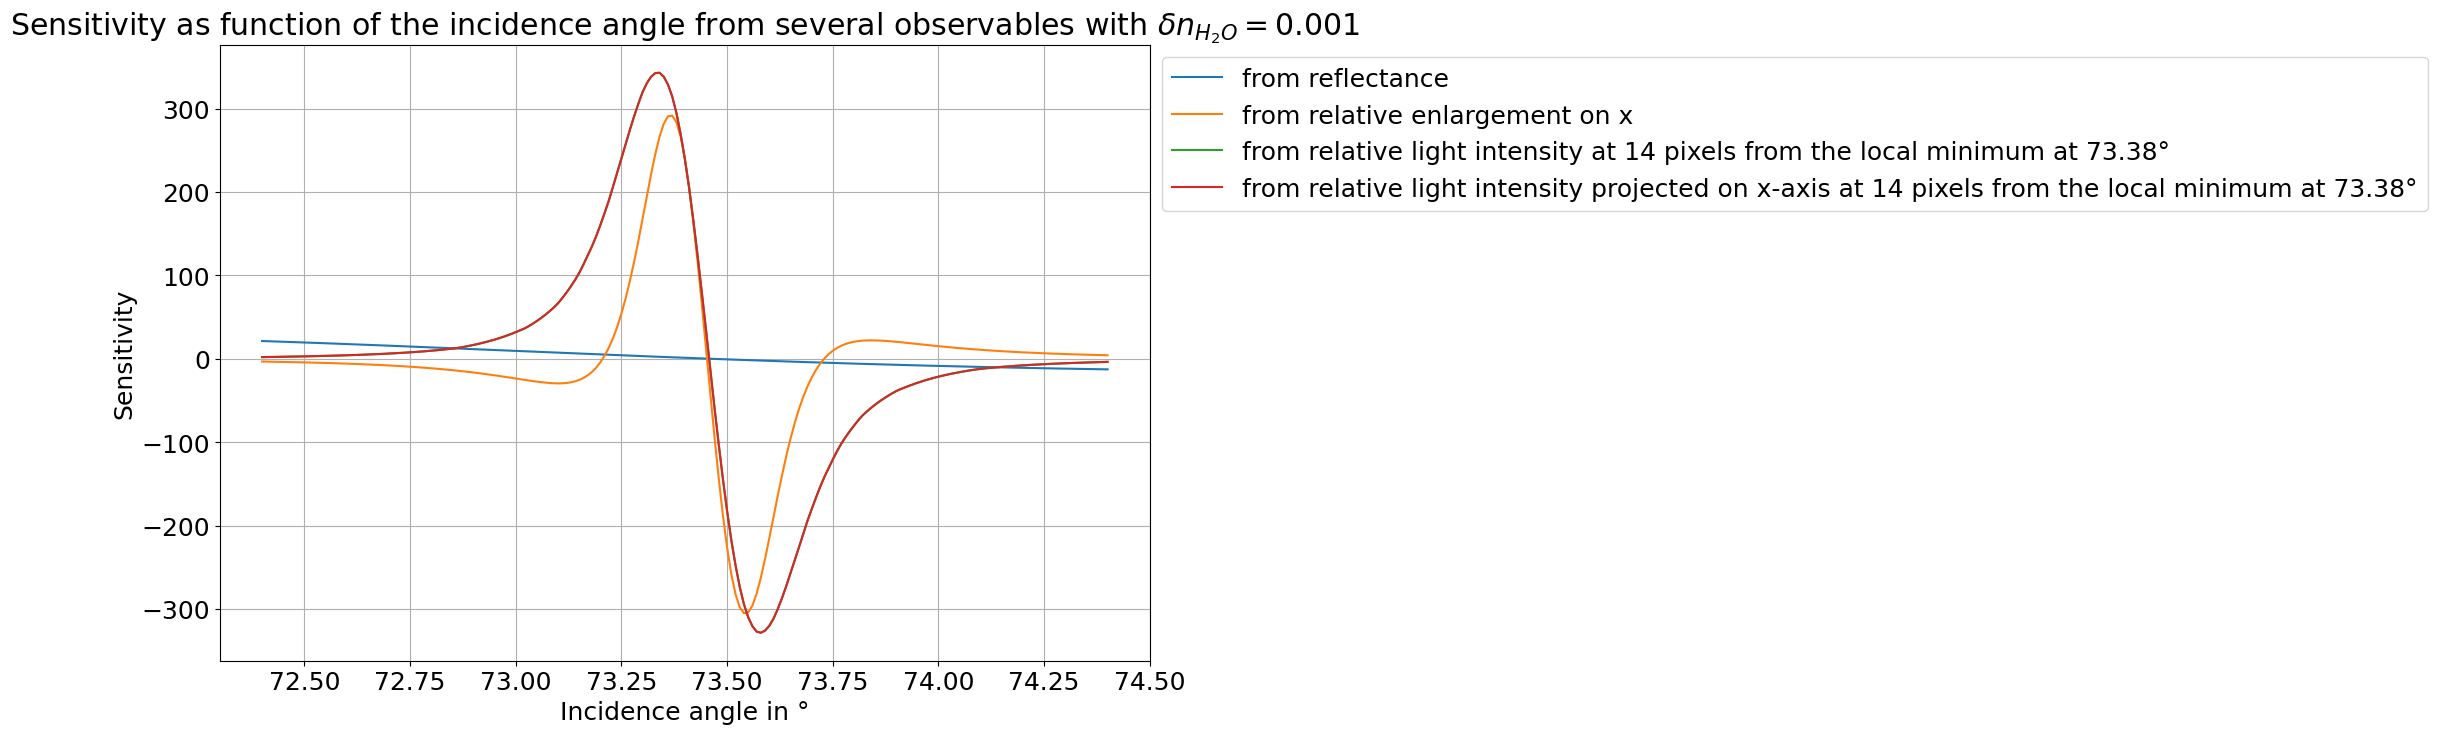

In [17]:
plt.figure(figsize=(12,8))
plt.plot(inc_range2, S_BASE, label="from reflectance")
plt.plot(inc_range2, S_ENLARG, label="from relative enlargement on x")
plt.plot(inc_range2, S_I_REL_MIN, label=f"from relative light intensity at {best_index} pixels from the local minimum at 73.38°")
plt.plot(inc_range2, S_I_PROJ_REL_MIN, label=f"from relative light intensity projected on x-axis at {best_index} pixels from the local minimum at 73.38°")
plt.title(fr"Sensitivity as function of the incidence angle from several observables with $\delta n_{{H_2O}} = ${n_variation}")
plt.xlabel("Incidence angle in °")
plt.ylabel("Sensitivity")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_sensitivity/sensitivity.{file_ext}", bbox_inches="tight")

print(f"Maximum sensitivity from reflectance is {np.max(np.abs(S_BASE)):.2f} at {inc_range2[np.argmax(np.abs(S_BASE))]:.2f}°.")
print(f"Maximum sensitivity from relative enlargement on x is {np.max(np.abs(S_ENLARG)):.2f} ({(np.max(np.abs(S_ENLARG))/np.max(np.abs(S_BASE))-1)*100:.2f}% improvement) at {inc_range2[np.argmax(np.abs(S_ENLARG))]:.2f}°.")
print(f"Maximum sensitivity relative light intensity at {best_index} pixels from the local minimum at 73.38° is {np.max(np.abs(S_I_REL_MIN)):.2f} ({(np.max(np.abs(S_I_REL_MIN))/np.max(np.abs(S_BASE))-1)*100:.2f}% improvement) at {inc_range2[np.argmax(np.abs(S_I_REL_MIN))]:.2f}°.")
print(f"Maximum sensitivity from relative light intensity projected on x-axis at {best_index} pixels from the local minimum at 73.38° is {np.max(np.abs(S_I_PROJ_REL_MIN)):.2f} ({(np.max(np.abs(S_I_PROJ_REL_MIN))/np.max(np.abs(S_BASE))-1)*100:.2f}% improvement) at {inc_range2[np.argmax(np.abs(S_I_PROJ_REL_MIN))]:.2f}°.")
print()
print("Sensitivity improvement in % vs reflectance canonical value (65):")
print(f"- relative enlargement on x-axis: {(np.max(np.abs(S_ENLARG))/65-1)*100:.2f}%")
print(f"- relative light intensity at {best_index} pixels from the local minimum at 73.38°: {(np.max(np.abs(S_I_REL_MIN))/65-1)*100:.2f}%")
print(f"- relative light intensity projected on x-axis at {best_index} pixels from the local minimum at 73.38°: {(np.max(np.abs(S_I_PROJ_REL_MIN))/65-1)*100:.2f}%")

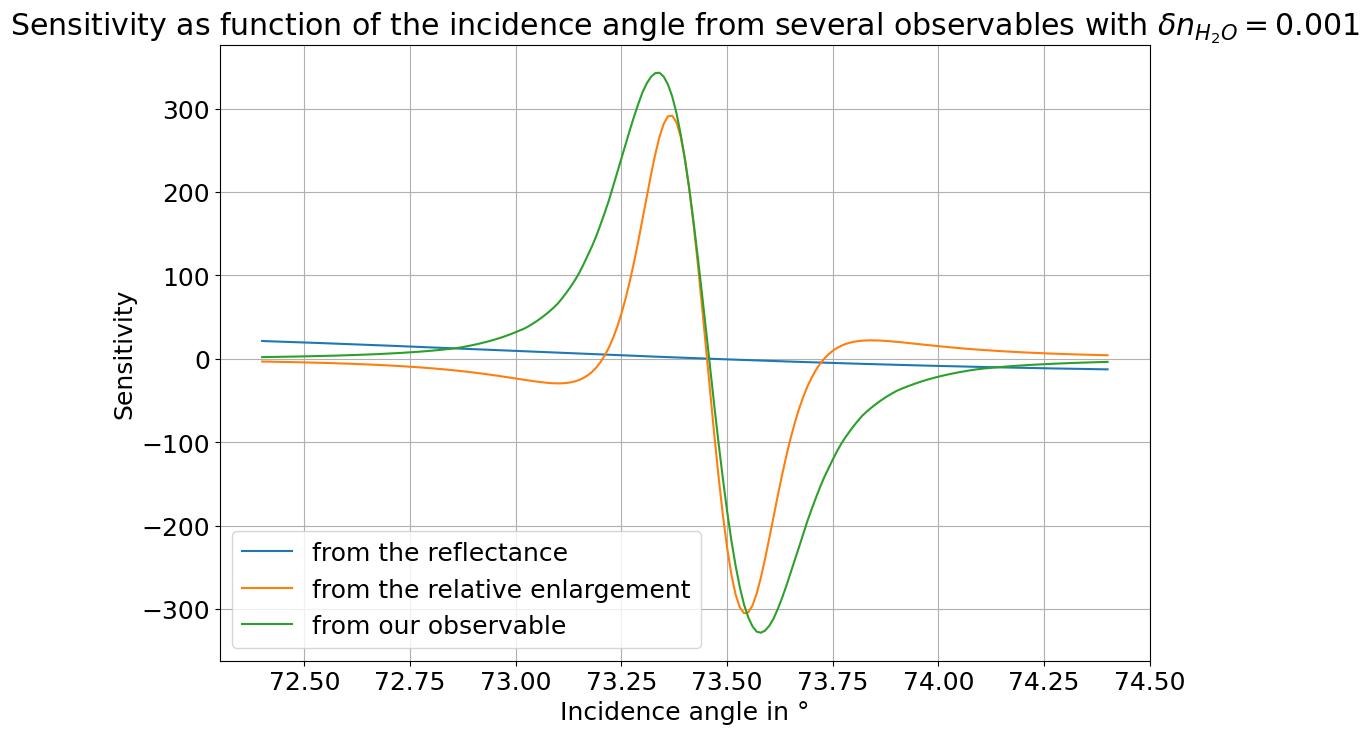

In [18]:
plt.figure(figsize=(12,8))
plt.plot(inc_range2, S_BASE, label="from the reflectance")
plt.plot(inc_range2, S_ENLARG, label="from the relative enlargement")
plt.plot(inc_range2, S_I_PROJ_REL_MIN, label=f"from our observable")
plt.title(fr"Sensitivity as function of the incidence angle from several observables with $\delta n_{{H_2O}} = ${n_variation}")
plt.xlabel("Incidence angle in °")
plt.ylabel("Sensitivity")
plt.legend(loc="best")
plt.grid();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_sensitivity/sensitivity_simple.{file_ext}", bbox_inches="tight")

### Sensitivity as function of the incidence angle (with R best sensitivity for each config)

In [19]:
def process_one_inc_w_best_r(inc):
    kz = ((n2 * k0) ** 2 - A**2 - B**2) ** 0.5
    theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2) / (n2 * k0))  # array with the incidence angle for all incident plane wave

    cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
    cr2 = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
    # determination of the reflection coefficients for each plane wave
    for i in range(len(a)):
        for j in range(len(b)):
            r, t, R, T = PM.coefficient(structure, wavelength, theta[i, j], 1)
            r2, t2, R2, T2 = PM.coefficient(structure2, wavelength, theta[i, j], 1)
            cr[i, j] = r
            cr2[i, j] = r2
    cr1D = np.abs(cr[N, :])**2
    cr21D = np.abs(cr2[N, :])**2
    
    s_base_list = (cr21D - cr1D) / n_variation
    s_base = s_base_list[np.argmax(np.abs(s_base_list))]

    # ------- base structure -------
    U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0)
    U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1)
    U1ki = cr * U1k
    U1i = ifft2(U1ki)

    bxU1 = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    byU1 = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)

    decx = bxU1i - bxU1
    decy = byU1i - byU1
    el1 = (trapezoid(trapezoid(((X - decx)**2) * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))

    I1 = (np.abs(U1i)**2)[::-1, ::-1]
    I1_rel = I1 / np.max(I1)
    if index_max_y < N:
        I_rel_min_1 = I1_rel[index_max_x, index_loc_min_y - num_best_neighbor]
    else:
        I_rel_min_1 = I1_rel[index_max_x, index_loc_min_y + num_best_neighbor]

    I_proj1 = np.sum(I1, axis=0)
    I_proj1_rel = I_proj1 / np.max(I_proj1)
    if ind_proj_max < N:
        I_proj_rel_min_1 = I_proj1_rel[ind_proj_loc_min - num_best_neighbor]
    else:
        I_proj_rel_min_1 = I_proj1_rel[ind_proj_loc_min + num_best_neighbor]

    # ------- modified structure -------
    U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0)
    U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1)
    U1ki = cr2 * U1k
    U1i = ifft2(U1ki)

    bxU1 = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    byU1 = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)

    decx = bxU1i - bxU1
    decy = byU1i - byU1
    el2 = (trapezoid(trapezoid(((X - decx)**2) * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))

    I2 = (np.abs(U1i)**2)[::-1, ::-1]
    I2_rel = I2 / np.max(I2)
    if index_max_y < N:
        I_rel_min_2 = I2_rel[index_max_x, index_loc_min_y - num_best_neighbor]
    else:
        I_rel_min_2 = I2_rel[index_max_x, index_loc_min_y + num_best_neighbor]

    I_proj2 = np.sum(I2, axis=0)
    I_proj2_rel = I_proj2 / np.max(I_proj2)
    if ind_proj_max < N:
        I_proj_rel_min_2 = I_proj2_rel[ind_proj_loc_min - num_best_neighbor]
    else:
        I_proj_rel_min_2 = I_proj2_rel[ind_proj_loc_min + num_best_neighbor]

    s_enlarg = (el2 - el1) / n_variation
    s_irel = (I_rel_min_2 - I_rel_min_1) / n_variation
    s_iproj = (I_proj_rel_min_2 - I_proj_rel_min_1) / n_variation
    
    s_iproj_list = (I_proj2_rel - I_proj1_rel) / n_variation
    s_iproj = s_iproj_list[np.argmax(np.abs(s_iproj_list))]

    return s_base, s_enlarg, s_irel, s_iproj


inc_range2 = np.linspace(72.4,74.4, int((74.4-72.4)/0.01)+1)

S_BASE = []
S_ENLARG = []
S_I_REL_MIN = []
S_I_PROJ_REL_MIN = []

results = Parallel(n_jobs=n_jobs)(
    delayed(process_one_inc_w_best_r)(inc) for inc in tqdm(inc_range2, desc="Scan of all the incidences")
)

for s_base, s_enlarg, s_irel, s_iproj in results:
    S_BASE.append(s_base)
    S_ENLARG.append(s_enlarg)
    S_I_REL_MIN.append(s_irel)
    S_I_PROJ_REL_MIN.append(s_iproj)

Scan of all the incidences: 100%|██████████| 201/201 [05:01<00:00,  1.50s/it]


Maximum sensitivity from reflectance is 28.89 at 72.72°.
Maximum sensitivity from relative enlargement on x is 305.19 (956.33% improvement) at 73.54°.
Maximum sensitivity relative light intensity at 14 pixels from the local minimum at 73.38° is 343.07 (1087.45% improvement) at 73.34°.
Maximum sensitivity from relative light intensity projected on x-axis at 14 pixels from the local minimum at 73.38° is 343.08 (1087.46% improvement) at 73.34°.

Sensitivity improvement in % vs reflectance canonical value (65):
- relative enlargement on x-axis: 369.52%
- relative light intensity at 14 pixels from the local minimum at 73.38°: 427.80%
- relative light intensity projected on x-axis at 14 pixels from the local minimum at 73.38°: 427.81%


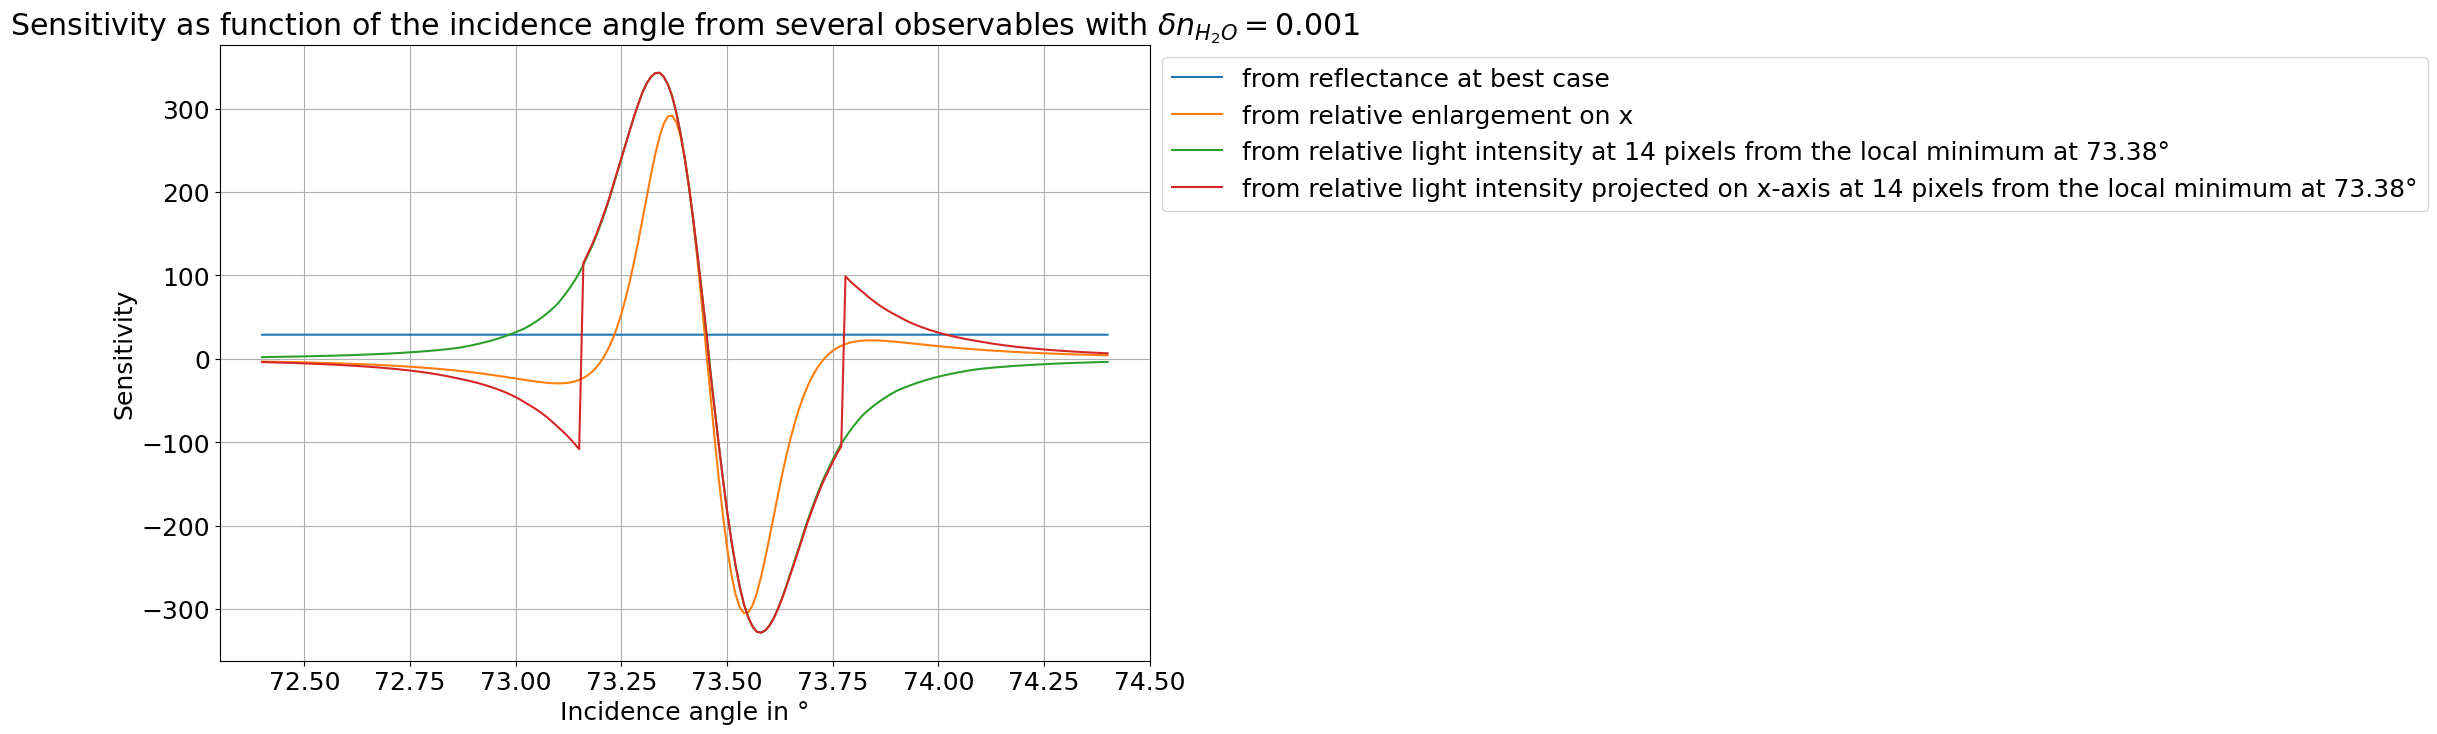

In [20]:
plt.figure(figsize=(12,8))
plt.plot(inc_range2, S_BASE, label="from reflectance at best case")
plt.plot(inc_range2, S_ENLARG, label="from relative enlargement on x")
plt.plot(inc_range2, S_I_REL_MIN, label=f"from relative light intensity at {best_index} pixels from the local minimum at 73.38°")
plt.plot(inc_range2, S_I_PROJ_REL_MIN, label=f"from relative light intensity projected on x-axis at {best_index} pixels from the local minimum at 73.38°")
plt.title(fr"Sensitivity as function of the incidence angle from several observables with $\delta n_{{H_2O}} = ${n_variation}")
plt.xlabel("Incidence angle in °")
plt.ylabel("Sensitivity")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_sensitivity/sensitivity_with_best_R.{file_ext}", bbox_inches="tight")

print(f"Maximum sensitivity from reflectance is {np.max(np.abs(S_BASE)):.2f} at {inc_range2[np.argmax(np.abs(S_BASE))]:.2f}°.")
print(f"Maximum sensitivity from relative enlargement on x is {np.max(np.abs(S_ENLARG)):.2f} ({(np.max(np.abs(S_ENLARG))/np.max(np.abs(S_BASE))-1)*100:.2f}% improvement) at {inc_range2[np.argmax(np.abs(S_ENLARG))]:.2f}°.")
print(f"Maximum sensitivity relative light intensity at {best_index} pixels from the local minimum at 73.38° is {np.max(np.abs(S_I_REL_MIN)):.2f} ({(np.max(np.abs(S_I_REL_MIN))/np.max(np.abs(S_BASE))-1)*100:.2f}% improvement) at {inc_range2[np.argmax(np.abs(S_I_REL_MIN))]:.2f}°.")
print(f"Maximum sensitivity from relative light intensity projected on x-axis at {best_index} pixels from the local minimum at 73.38° is {np.max(np.abs(S_I_PROJ_REL_MIN)):.2f} ({(np.max(np.abs(S_I_PROJ_REL_MIN))/np.max(np.abs(S_BASE))-1)*100:.2f}% improvement) at {inc_range2[np.argmax(np.abs(S_I_PROJ_REL_MIN))]:.2f}°.")
print()
print("Sensitivity improvement in % vs reflectance canonical value (65):")
print(f"- relative enlargement on x-axis: {(np.max(np.abs(S_ENLARG))/65-1)*100:.2f}%")
print(f"- relative light intensity at {best_index} pixels from the local minimum at 73.38°: {(np.max(np.abs(S_I_REL_MIN))/65-1)*100:.2f}%")
print(f"- relative light intensity projected on x-axis at {best_index} pixels from the local minimum at 73.38°: {(np.max(np.abs(S_I_PROJ_REL_MIN))/65-1)*100:.2f}%")

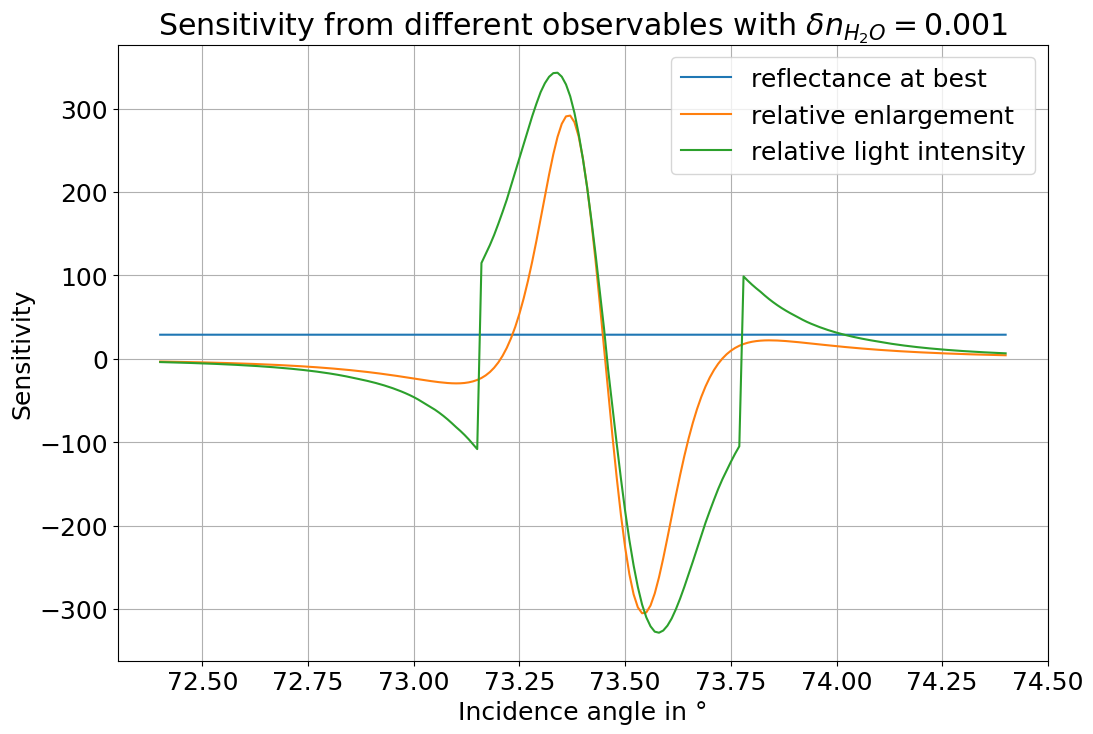

In [21]:
plt.figure(figsize=(12,8))
plt.plot(inc_range2, S_BASE, label="reflectance at best")
plt.plot(inc_range2, S_ENLARG, label="relative enlargement")
plt.plot(inc_range2, S_I_PROJ_REL_MIN, label=f"relative light intensity")
plt.title(fr"Sensitivity from different observables with $\delta n_{{H_2O}} = ${n_variation}")
plt.xlabel("Incidence angle in °")
plt.ylabel("Sensitivity")
plt.legend(loc="best")
plt.grid();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_sensitivity/sensitivity_simple_with_best_R.{file_ext}", bbox_inches="tight")

# Search of the best possible sensitivity for the reflexion coefficient (with several gold layer thickness)

In [22]:
def process_one_inc_structs(inc):
    kz = ((n2 * k0) ** 2 - A**2 - B**2) ** 0.5
    theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2) / (n2 * k0))  # array with the incidence angle for all incident plane wave

    cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
    cr2 = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
    # determination of the reflection coefficients for each plane wave
    for i in range(len(a)):
        for j in range(len(b)):
            r, t, R, T = PM.coefficient(structure_it, wavelength, theta[i, j], 1)
            r2, t2, R2, T2 = PM.coefficient(structure2_it, wavelength, theta[i, j], 1)
            cr[i, j] = r
            cr2[i, j] = r2
    
    s_base_array = (np.abs(cr2)**2 - np.abs(cr)**2) / n_variation
    index_best_s_base = np.unravel_index(np.argmax(np.abs(s_base_array), axis=None), s_base_array.shape)
    s_base = s_base_array[index_best_s_base]
    
    return s_base

gold_thickness_range=np.arange(20,56,1)
inc_range_full=np.linspace(70.5,74.5, int((74.5-70.5)/0.01)+1) # range of incidence considered

# n_variation = 0.001

Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")

S_BASE_GOLD = []

for h_Au_it in gold_thickness_range:
    print(f"Gold layer thickness : {h_Au_it} nm")
    # definition of the structure on which the reflection is done
    # get the material from refractiveindex database (RII) when possible
    mat = ["BK7",Cr,Au,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33**2 is for water
    stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
    thickness = [4000, 2, h_Au_it, 1000]  # thickness of each layer
    structure_it = PM.Structure(mat, stack, thickness, verbose=False)
    mat2 = ["BK7",Cr,Au,(1.33+n_variation)**2]  # same list of material as before but with a slight modification of the water permittivity
    structure2_it = PM.Structure(mat2, stack, thickness, verbose=False)
    
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_one_inc_structs)(inc) for inc in tqdm(inc_range_full, desc="Scan of all the incidences")
    )
    
    S_BASE_GOLD.append(results[np.argmax(np.abs(results))])

Gold layer thickness : 20 nm


Scan of all the incidences:  58%|█████▊    | 234/401 [05:58<04:41,  1.68s/it]

KeyboardInterrupt: 

The best sensitivity is for h_Au = 51 nm with sensitivity = 29.854307683206322

Sensitivity improvement in % vs reflectance best:
- relative enlargement on x-axis: 922.26%
- relative light intensity at 14 pixels from the local minimum at 73.38°: 1049.15%
- relative light intensity projected on x-axis at 14 pixels from the local minimum at 73.38°: 1049.17%


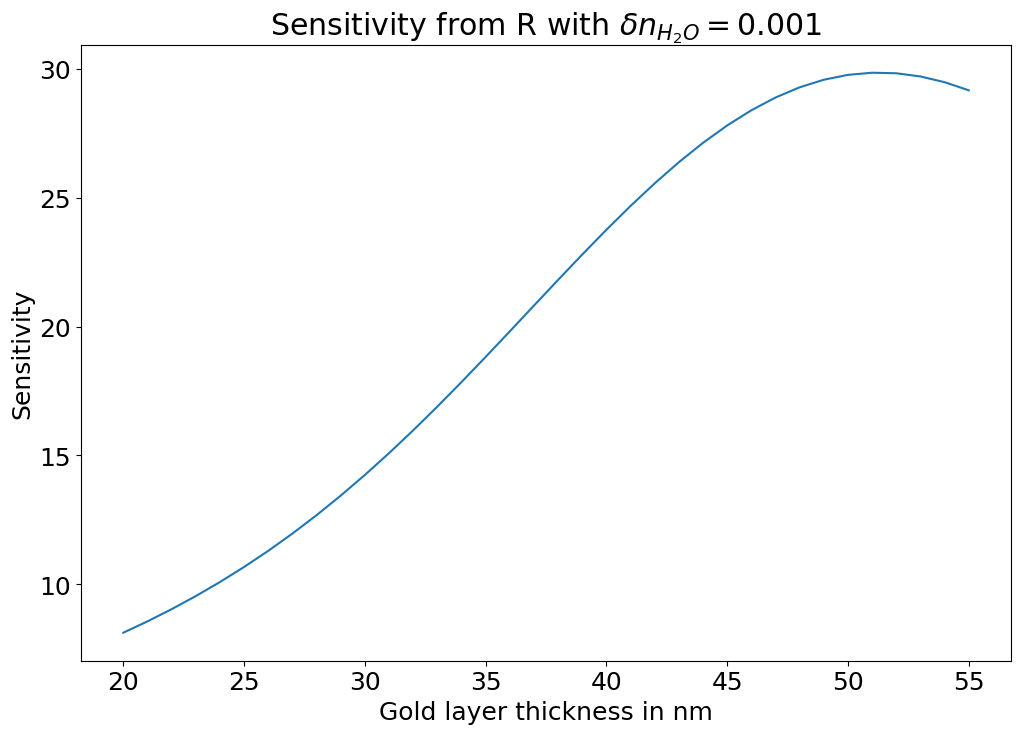

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(gold_thickness_range, S_BASE_GOLD)
plt.title(fr"Sensitivity from R with $\delta n_{{H_2O}} = ${n_variation}")
plt.xlabel("Gold layer thickness in nm")
plt.ylabel("Sensitivity")
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_sensitivity/R_sensitivity_simple_with_best_as_function_of_gold_thickness.{file_ext}", bbox_inches="tight")

print(f"The best sensitivity is for h_Au = {gold_thickness_range[np.argmax(np.abs(S_BASE_GOLD))]} nm with sensitivity = {S_BASE_GOLD[np.argmax(np.abs(S_BASE_GOLD))]}");
print()
print("Sensitivity improvement in % vs reflectance best:")
print(f"- relative enlargement on x-axis: {(np.max(np.abs(S_ENLARG))/S_BASE_GOLD[np.argmax(np.abs(S_BASE_GOLD))]-1)*100:.2f}%")
print(f"- relative light intensity at {best_index} pixels from the local minimum at 73.38°: {(np.max(np.abs(S_I_REL_MIN))/S_BASE_GOLD[np.argmax(np.abs(S_BASE_GOLD))]-1)*100:.2f}%")
print(f"- relative light intensity projected on x-axis at {best_index} pixels from the local minimum at 73.38°: {(np.max(np.abs(S_I_PROJ_REL_MIN))/S_BASE_GOLD[np.argmax(np.abs(S_BASE_GOLD))]-1)*100:.2f}%")